# EDA — Breast Cancer Wisconsin

Разведочный анализ датасета для задачи бинарной классификации опухолей.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)

## 1. Загрузка данных

In [2]:
raw = load_breast_cancer(as_frame=True)
df = raw.frame
df.rename(columns={'target': 'label'}, inplace=True)
# label: 0 = malignant, 1 = benign
df.to_csv(DATA_DIR / 'breast_cancer_orig.csv', index=False)
print(f'Shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')
df.head()

Shape: (569, 31)
Label distribution:
label
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Базовая статистика

In [3]:
print(df.describe().T[['mean', 'std', 'min', 'max']].to_string())

                               mean         std         min         max
mean radius               14.127292    3.524049    6.981000    28.11000
mean texture              19.289649    4.301036    9.710000    39.28000
mean perimeter            91.969033   24.298981   43.790000   188.50000
mean area                654.889104  351.914129  143.500000  2501.00000
mean smoothness            0.096360    0.014064    0.052630     0.16340
mean compactness           0.104341    0.052813    0.019380     0.34540
mean concavity             0.088799    0.079720    0.000000     0.42680
mean concave points        0.048919    0.038803    0.000000     0.20120
mean symmetry              0.181162    0.027414    0.106000     0.30400
mean fractal dimension     0.062798    0.007060    0.049960     0.09744
radius error               0.405172    0.277313    0.111500     2.87300
texture error              1.216853    0.551648    0.360200     4.88500
perimeter error            2.866059    2.021855    0.757000    2

## 3. Проверка на пропуски

In [4]:
missing = df.isnull().sum()
print(f'Missing values: {missing.sum()} (all zeros = clean dataset)')

Missing values: 0 (all zeros = clean dataset)


## 4. Распределение классов

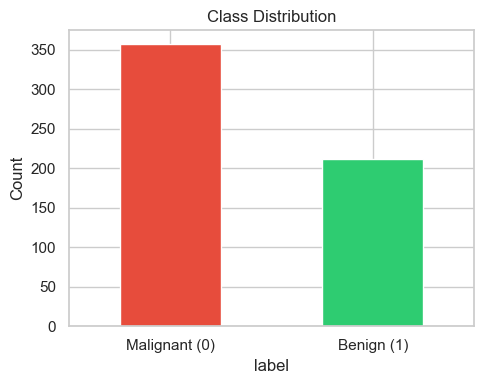

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
df['label'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['Malignant (0)', 'Benign (1)'], rotation=0)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=100)
plt.show()

## 5. Корреляция топ-10 признаков с меткой

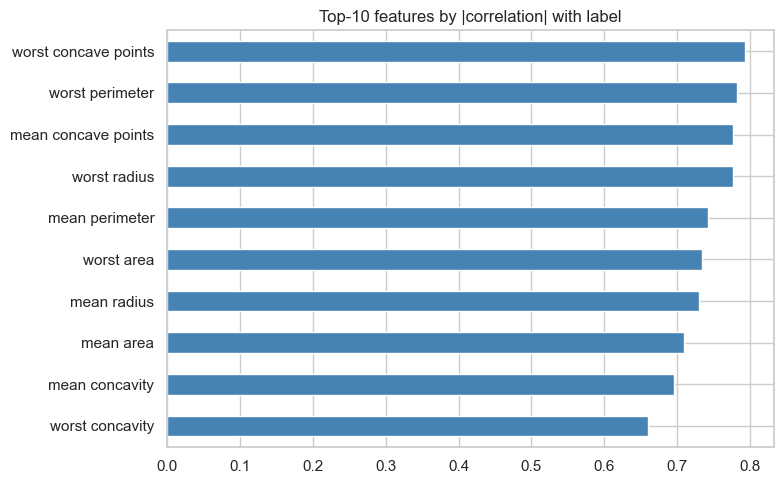

Top-10 features:
 worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610


In [6]:
corr = df.corr()['label'].drop('label').abs().sort_values(ascending=False)
top10 = corr.head(10)

fig, ax = plt.subplots(figsize=(8, 5))
top10.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top-10 features by |correlation| with label')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/top10_correlations.png', dpi=100)
plt.show()

print('Top-10 features:\n', top10.to_string())

## 6. Вывод

- Датасет чистый (0 пропусков), 569 записей, 30 признаков
- Классы: 212 malignant (37%), 357 benign (63%) — умеренный дисбаланс
- Топ признаки: worst radius, worst perimeter, worst area (высокая корреляция с меткой)
- Данные сохранены в `data/breast_cancer_orig.csv`